# MOPED: fixed-noise Battaglia12 diagnostic

This compares the original observation (noise seed 3000001) with a newly simulated Battaglia12 observation using the legacy training noise seed 12345. Both use mask seed 12345, baseline deproj0, the same 2 arcmin beam, saved binning, asinh and MOPED transform, and the same trained density estimator.

**Diagnostic only:** this NPE learned a mapping with a reused noise realization. The displayed widths are not validated uncertainties for independent SO noise. No prior bounds, learned weights or compression statistics have been changed.

Run all cells to inspect the completed local results. The two rerun switches below default to False; viewing the plots does not generate maps or resample.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "SBI_analysis/so_moped_local.py").is_file()), None)
if REPO is None:
    raise FileNotFoundError("Open this notebook inside the HalfDome checkout.")
sys.path.insert(0, str(REPO / "SBI_analysis"))
from so_moped_local import load_bundle, prepare_context, simulate
from so_sbi_compression import FIDUCIAL, PARAM_NAMES, save_npz
from export_so_moped_bundle import sha256

BUNDLE = REPO / "SBI_analysis/outputs/compression_bestval_20260909/moped_bundle"
ORIGINAL = REPO / "SBI_analysis/outputs/moped_local_profiles/0669be4fb61ca0d5"
FIXED = ORIGINAL / "fixed_noise_diagnostic"
DIAGNOSTICS = FIXED / "diagnostics"

RUN_SIMULATION = False
RERUN_DIAGNOSTICS_AND_SAMPLING = False
NUM_SAMPLES = 10000
contract, transform, manifest = load_bundle(BUNDLE)
print("Results:", DIAGNOSTICS)


Results: /home/cbllover/HalfDome/SBI_analysis/outputs/moped_local_profiles/0669be4fb61ca0d5/fixed_noise_diagnostic/diagnostics


## Optional reproduction

The next cell uses the existing full-sky training simulator and all nine Battaglia12 inputs, with a fresh parameter-specific interpolator cache. It deliberately retains mask and noise seed 12345. Completed simulation files are reused only when command, source hashes and raw spectrum checksum still match. No training dataset is overwritten.

Keep the Julia environment and catalogue paths consistent with the local simulator. Different software versions are not guaranteed to reproduce identical random maps from the same seed.


In [2]:
if RUN_SIMULATION:
    raw = simulate(
        REPO, FIXED, REPO / "lightcone_100.hdf5",
        REPO / "other_sims/SO/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt",
        FIDUCIAL,
        julia="/home/kn18001/.julia/juliaup/julia-1.12.2+0.x64.linux.gnu/bin/julia",
        julia_project="/home/kn18001/.julia/environments/v1.12",
        julia_depot="/home/kn18001/.julia",
        threads=16, mask_seed=12345, noise_seed=12345,
    )
    x, context = prepare_context(raw, contract, transform)
    save_npz(FIXED / "observation.npz", x=x, context=context,
             theta=FIDUCIAL, param_names=np.asarray(PARAM_NAMES))

if RERUN_DIAGNOSTICS_AND_SAMPLING:
    import subprocess
    subprocess.run([
        sys.executable, str(REPO / "SBI_analysis/diagnose_so_moped_observation.py"),
        "--observation-dir", str(FIXED),
        "--compare-observation-dir", str(ORIGINAL),
        "--bundle", str(BUNDLE), "--fixed-noise-posterior",
        "--posterior-samples", str(NUM_SAMPLES),
    ], check=True, cwd=REPO)


## Support and provenance checks

The first table uses 20,000 untruncated proposals for each observation and checks the saved nine-dimensional prior. This is a sampling-support diagnostic, not a coverage test. The training coordinate ranges and residual scatter are descriptive references, not a Gaussian likelihood or an outlier p-value.

The diagnostic also verifies theta/Sobol alignment for the paired training products, exact reproduction of saved preprocessing, cluster/local density log probabilities, and matching physical settings and source hashes between the two new simulations.


In [3]:
report = json.loads((DIAGNOSTICS / "observation_diagnosis.json").read_text())
sampling = json.loads((DIAGNOSTICS / "fixed_noise_sampling_summary.json").read_text())
assert report["experiment_id"] == manifest["experiment_id"] == sampling["experiment_id"]
assert report["preprocessing_reproduces_saved_context"]
assert report["paired_data_alignment_passed"]
assert report["local_cluster_model_log_prob_passed"]
assert report["comparison"]["matched_physics_and_source_hashes"]
assert sampling["conditional_on_fixed_noise"] and not sampling["independent_noise_validated"]
assert sha256(FIXED / "posterior_samples.npy") == sampling["samples_sha256"]

table = pd.DataFrame([
    {"observation": "Independent noise", "seed": report["comparison"]["noise_seed"],
     "pilot_acceptance_percent": 100 * report["comparison"]["raw_prior_acceptance"],
     "max_abs_MOPED_coordinate": np.max(np.abs(report["comparison"]["context"]))},
    {"observation": "Fixed-noise diagnostic", "seed": report["noise_seed"],
     "pilot_acceptance_percent": 100 * report["raw_prior_acceptance"],
     "max_abs_MOPED_coordinate": np.max(np.abs(report["context"]))},
])
display(table)
print("Saved posterior samples:", sampling["n_samples"])
print("Actual sampling acceptance:", f'{sampling["raw_prior_acceptance"]:.3%}')
print("Checks passed. This does not establish calibration.")


,observation,seed,pilot_acceptance_percent,max_abs_MOPED_coordinate
0,Independent noise,3000001,0.000,181.033920
1,Fixed-noise diagnostic,12345,99.455,0.617423


Saved posterior samples: 10000
Actual sampling acceptance: 99.512%
Checks passed. This does not establish calibration.


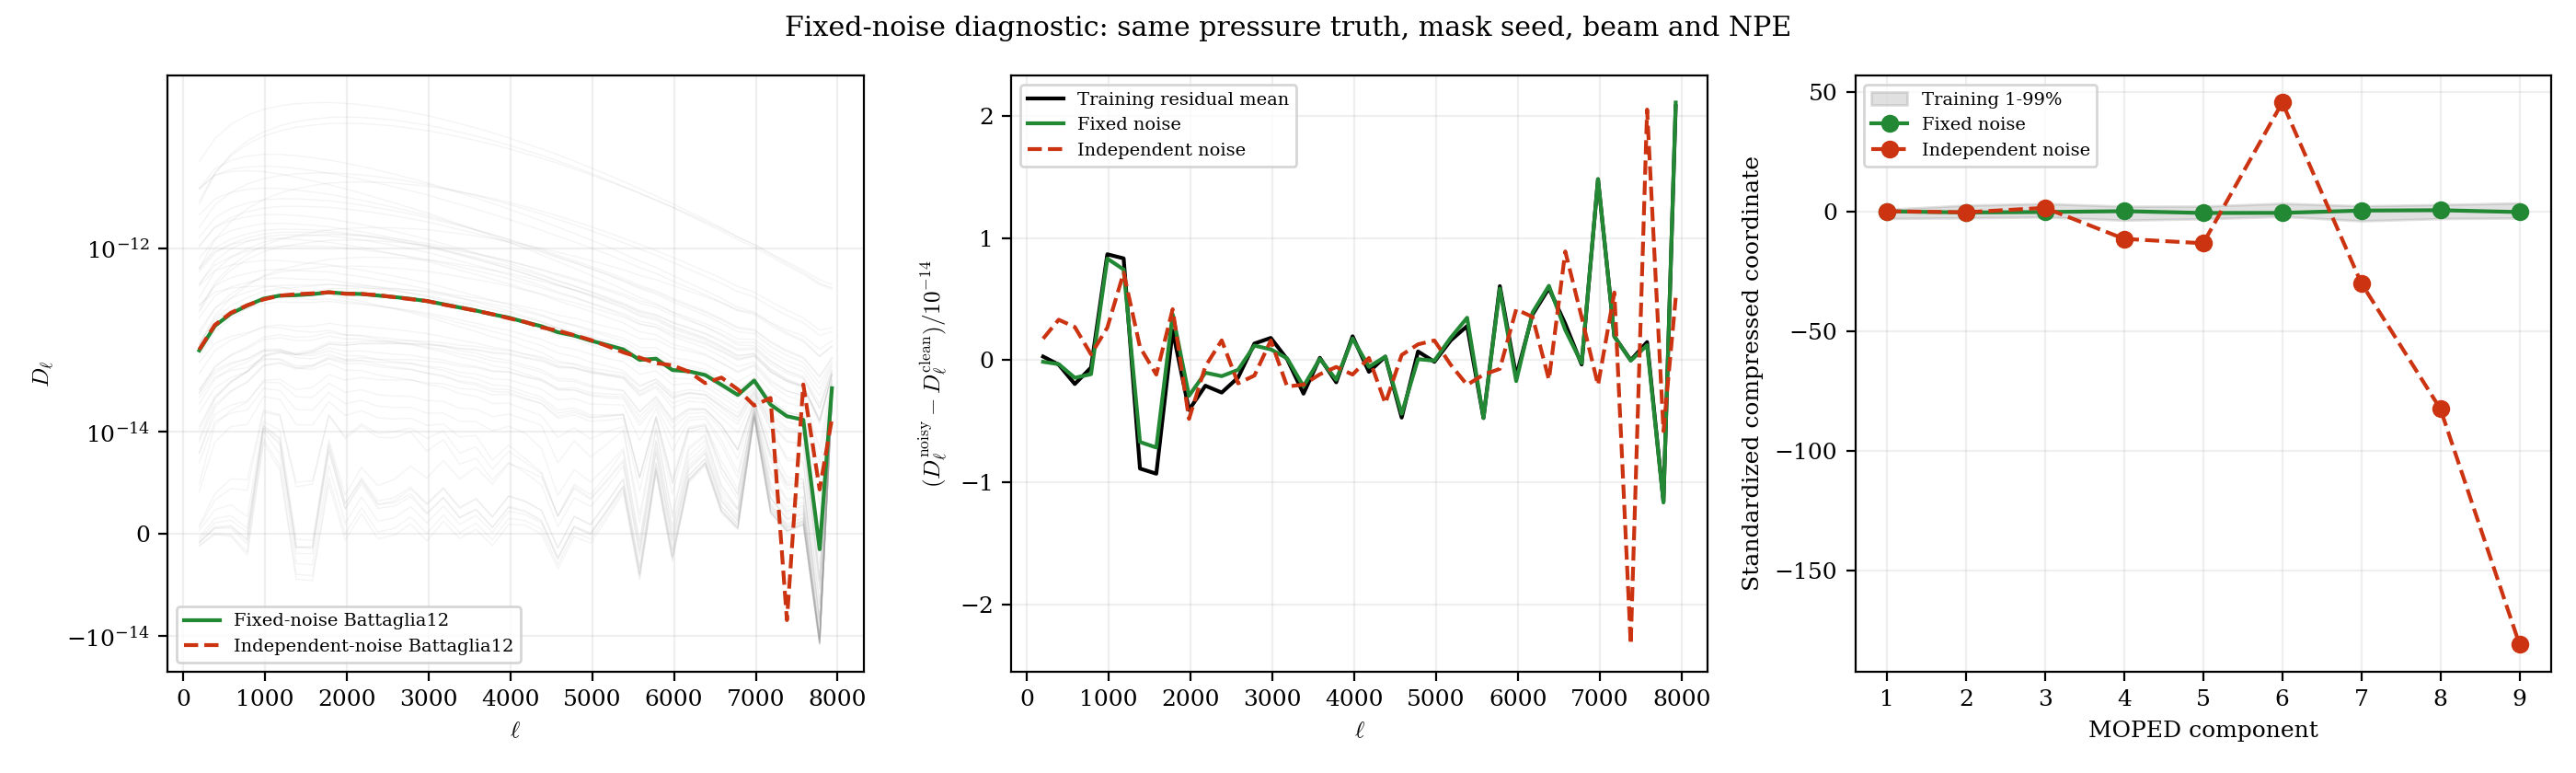

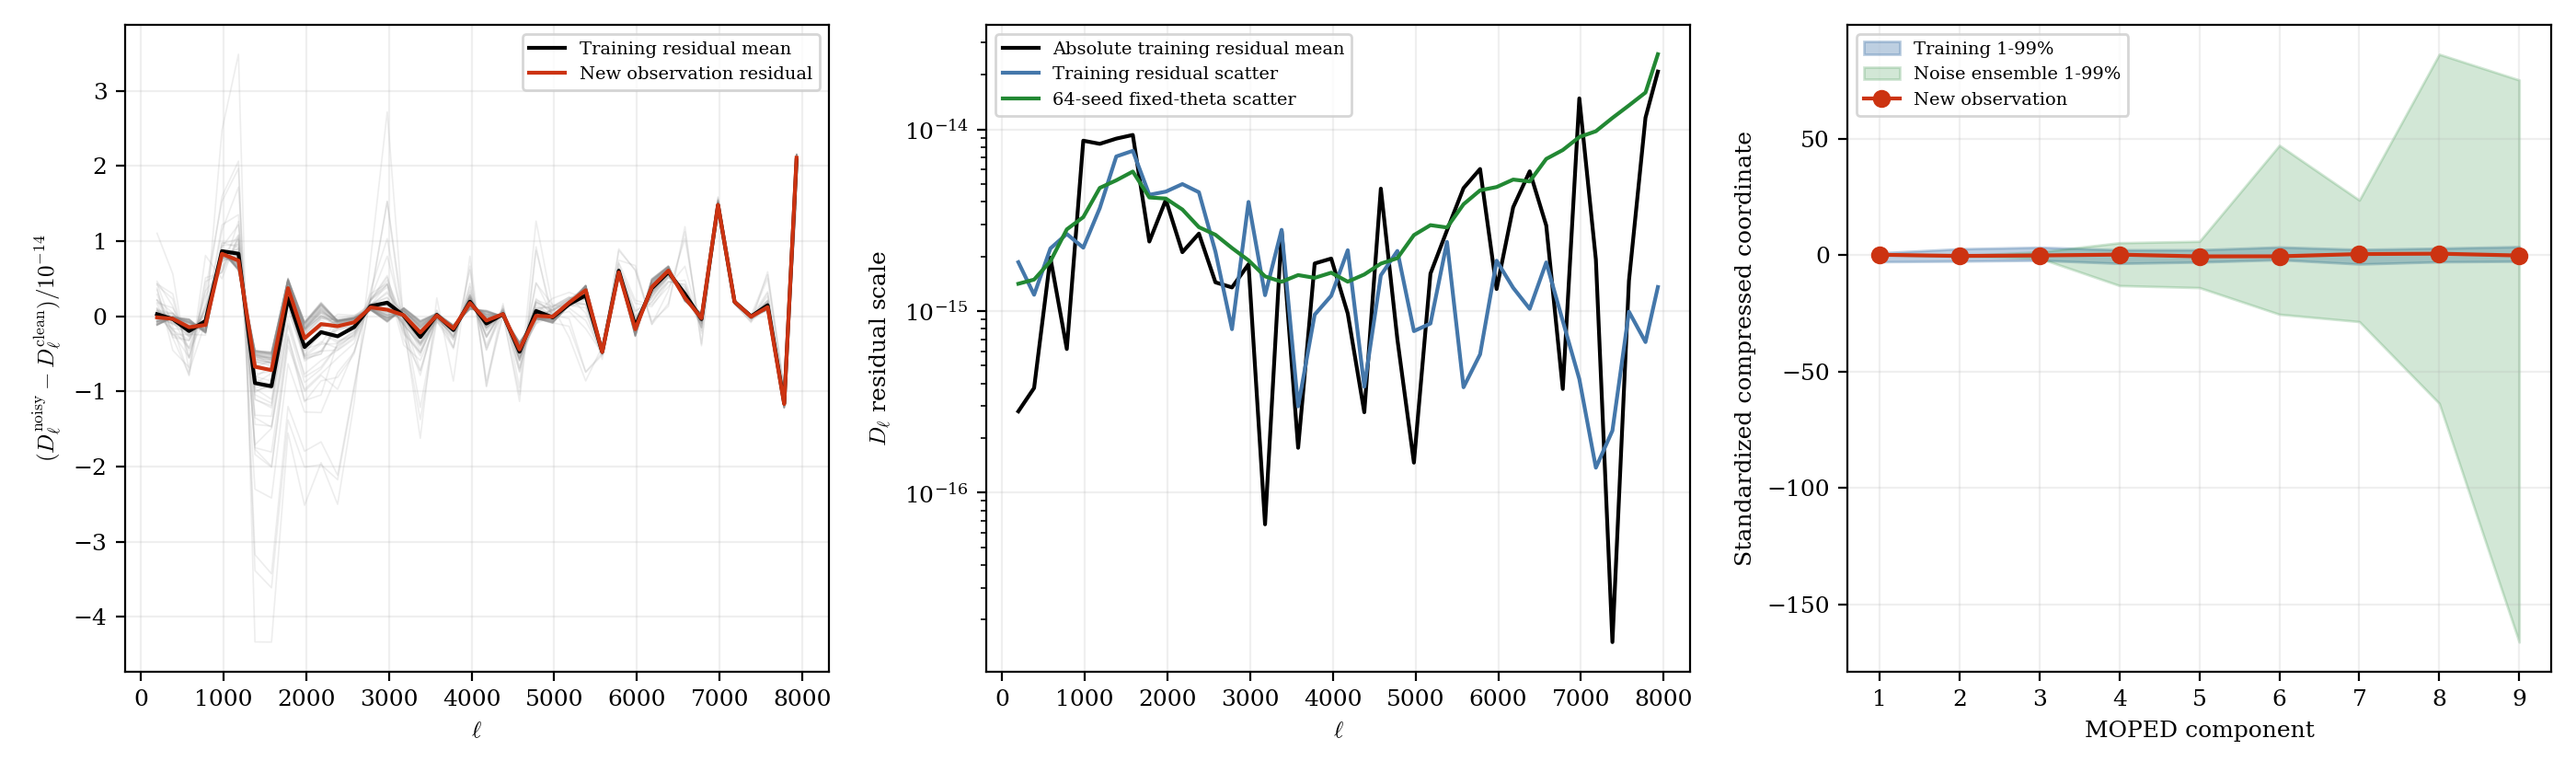

In [4]:
display(Image(filename=str(DIAGNOSTICS / "fixed_vs_independent_noise.png")))
display(Image(filename=str(DIAGNOSTICS / "noise_contract_diagnosis.png")))


## Conditional constraints

Black dotted lines mark Battaglia12 truth; the green contours are the prior-restricted learned NPE at the fixed-noise observation. These are independent draws, not an MCMC chain. The per-parameter pull is (posterior mean - truth) / posterior standard deviation. One observation cannot supply a correlation coefficient, RMSE convergence curve or SBC calibration.

The training cross spectrum contains signal-signal, two signal-noise terms and a noise-noise term. Reusing noise maps across theta rows preserves a coherent residual pattern. Independent noise changes that pattern; MOPED strongly amplifies directions that were nearly constant in the fixed-noise training data. This explains why similar-looking raw spectra can have very different compressed contexts.

The locally fitted MOPED residual covariance is therefore **not an independent-noise likelihood covariance**. It may be used here as the already-trained deterministic feature transform, but its interpretation as SO noise whitening needs revision. A scientifically noise-marginalized SBI/Fisher comparison requires matched stochastic training and covariance models.


,param,truth,posterior_mean,posterior_std,pull,error_over_prior
0,P0,18.10000,18.557010,1.057467,0.432174,0.014058
1,xc,0.49700,0.488823,0.042443,-0.192665,-0.011774
2,beta,4.35000,4.312066,0.224101,-0.169273,-0.021852
3,alpha_m_P0,0.15400,0.147964,0.020335,-0.296839,-0.020676
4,alpha_m_xc,-0.00865,-0.003020,0.032750,0.171903,0.028218
5,alpha_m_beta,0.03930,0.042418,0.021038,0.148218,0.026050
6,alpha_z_P0,-0.75800,-0.782719,0.064472,-0.383408,-0.021786
7,alpha_z_xc,0.73100,0.742884,0.086738,0.137007,0.010182
8,alpha_z_beta,0.41500,0.416621,0.051983,0.031184,0.002448


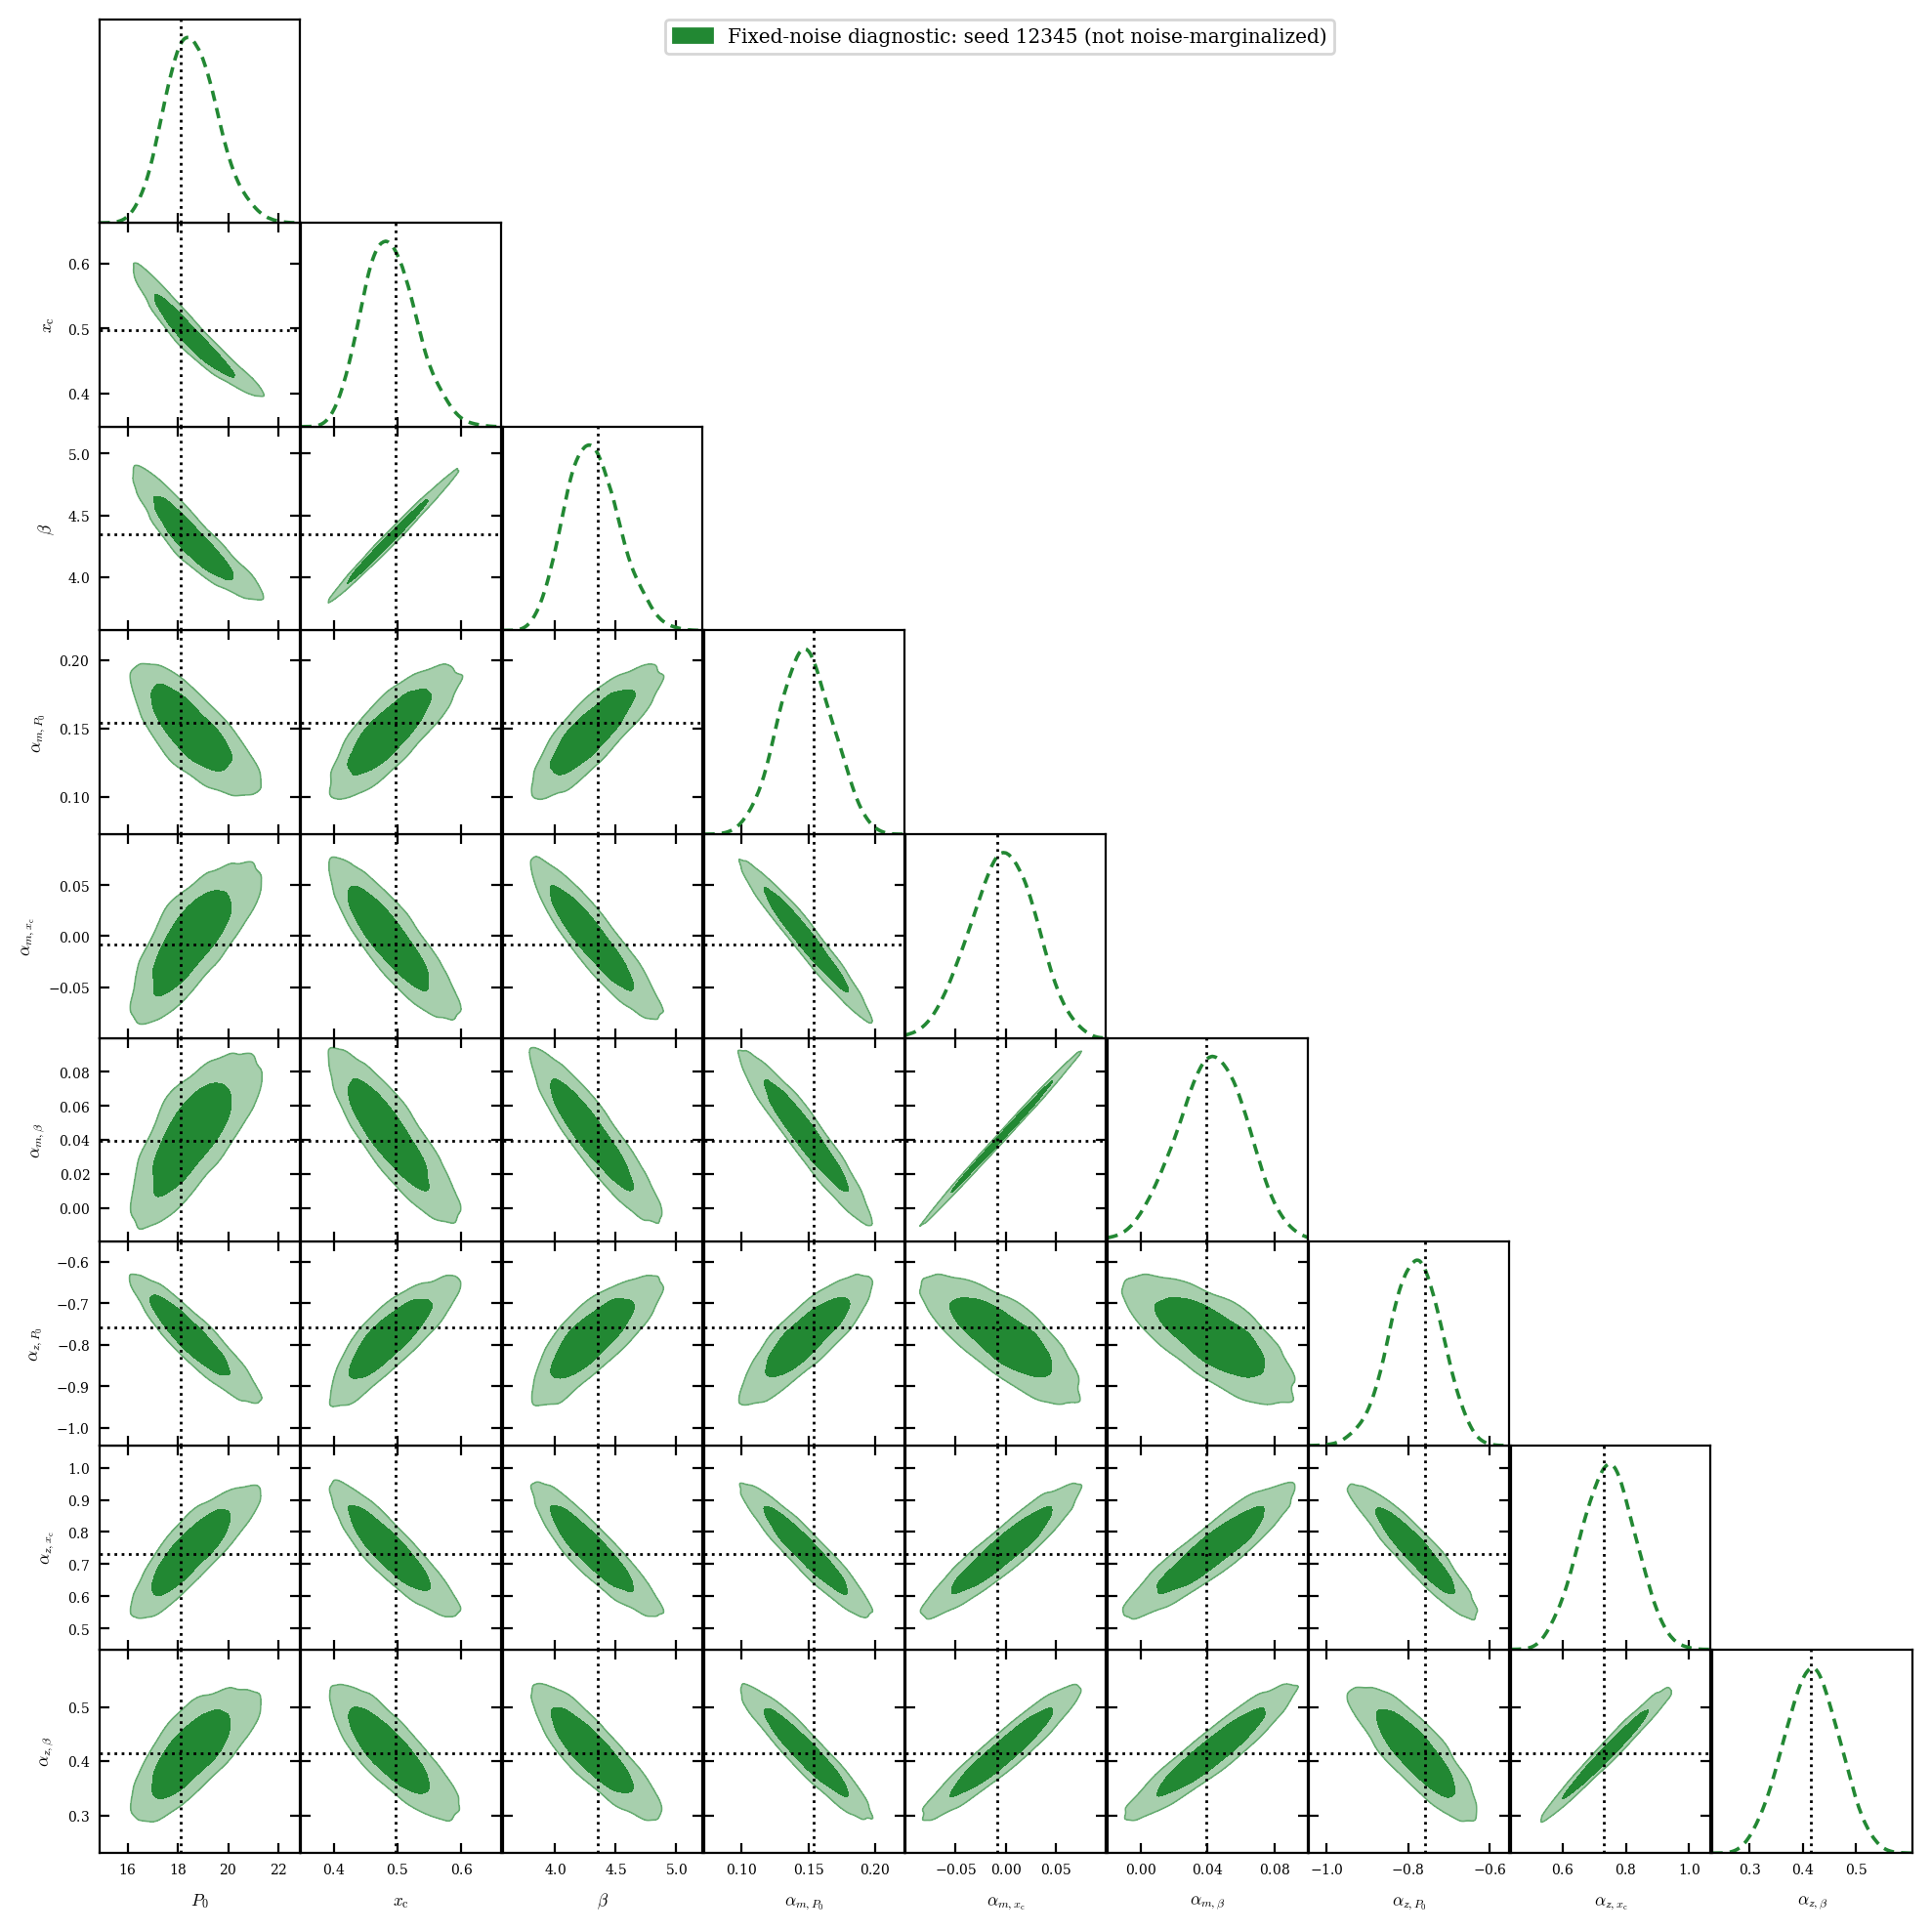

In [5]:
samples = np.load(FIXED / "posterior_samples.npy")
assert samples.shape == (sampling["n_samples"], len(PARAM_NAMES))
assert np.isfinite(samples).all()
assert np.all((samples >= contract["low"]) & (samples <= contract["high"]))
metrics = pd.read_csv(DIAGNOSTICS / "posterior_metrics.csv")
display(metrics)
display(Image(filename=str(DIAGNOSTICS / "moped_sbi_corner.png"), width=1000))
